In [1]:
import inspect
import time

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

In [24]:
def wrangle(filepath, resample_rule="1H"):
    # Read Data into DataFrame
    df = pd.read_csv(filepath)

    # Select only the needed columns `date` and `pm2_5`
    df = df[["date", "pm2_5"]]

    # Change the name of the index
    df = df.rename(columns={"date": "timestamp"})

    # Change `date` string to datetime
    df["timestamp"] = pd.to_datetime(df["timestamp"], dayfirst=True)

    # Set `time` as the index
    df = df.set_index("timestamp")

    # Localize timezone and convert to Nairobi's timezone
    df.index = df.index.tz_localize("UTC").tz_convert("Africa/Nairobi")

    # Remove outliers
    df = df[df["pm2_5"] < 50]

    # Resample to 1hr window. Remove `.to_frame()` to convert from dataframe to series
    y = df["pm2_5"].resample(resample_rule).mean().fillna(method="ffill")

    return y

In [25]:
filepath = r"C:\Users\Johnt\Downloads\Time Series Dar Es Salaam - Tanzania\air_quality_historical.csv"

In [35]:
df = wrangle(filepath, resample_rule="1H")
df.head()

C:\Users\Johnt\AppData\Local\Temp\ipykernel_3668\1561736669.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  y = df["pm2_5"].resample(resample_rule).mean().fillna(method="ffill")
C:\Users\Johnt\AppData\Local\Temp\ipykernel_3668\1561736669.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y = df["pm2_5"].resample(resample_rule).mean().fillna(method="ffill")


timestamp
2022-08-04 03:00:00+03:00    11.138095
2022-08-04 04:00:00+03:00    11.138095
2022-08-04 05:00:00+03:00    11.138095
2022-08-04 06:00:00+03:00    11.138095
2022-08-04 07:00:00+03:00    11.138095
Freq: h, Name: pm2_5, dtype: float64

EXPLORING THE DATA

Plotting the ACF and PACF Plots

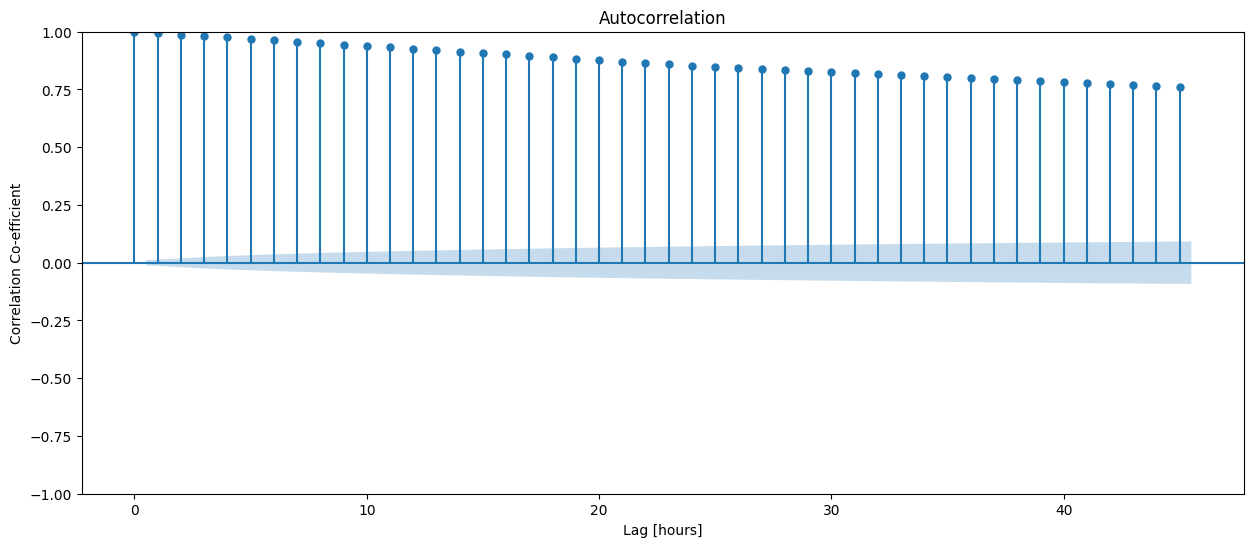

In [37]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_acf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Co-efficient");

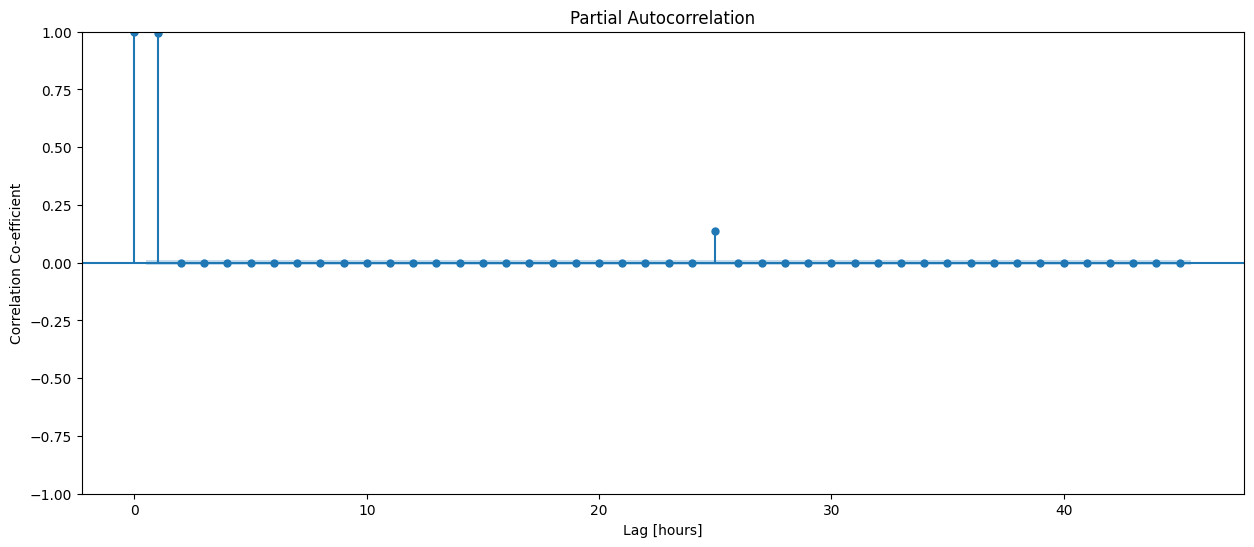

In [38]:
fig, ax = plt.subplots(figsize=(15, 6))

plot_pacf(df, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Co-efficient");

In [44]:
df.isnull()

timestamp
2022-08-04 03:00:00+03:00    False
2022-08-04 04:00:00+03:00    False
2022-08-04 05:00:00+03:00    False
2022-08-04 06:00:00+03:00    False
2022-08-04 07:00:00+03:00    False
                             ...  
2026-02-17 23:00:00+03:00    False
2026-02-18 00:00:00+03:00    False
2026-02-18 01:00:00+03:00    False
2026-02-18 02:00:00+03:00    False
2026-02-18 03:00:00+03:00    False
Freq: h, Name: pm2_5, Length: 31057, dtype: bool

SPLIT

In [48]:
cutoff_test = int(len(df) * 0.95)

df_train = df["2026-01"]
df_test = df["2026-02-01"]

BUILD MODEL

Baseline

In [49]:
df_train_mean = df_train.mean()

df_pred_baseline = [df_train_mean] * len(df_train)
mae_baseline = mean_absolute_error(df_train, df_pred_baseline)

print("Mean pm2_5 Reading:", round(df_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean pm2_5 Reading: 11.36
Baseline MAE: 2.17


Iterate

Hyperparameter Range

In [63]:
p_params = range(0, 25, 8)
q_params = range(0, 3, 1)

In [64]:
# Create empty dictionary for MAE values
mae_grid = {}
for p in p_params:
    # Create new key in dictionary with empty list
    mae_grid[p] = []
    for q in q_params:
        # Set the hyperparameters for the model
        order = (p, 0, q)
        # Start timing
        start_time = time.time()
        # Train Model
        model = ARIMA(df_train, order=order).fit()
        # Calculate the elapsed time
        elapsed_time = round((time.time() - start_time), 2)
        print(f"Trained ARIMA model {order} in {elapsed_time} seconds.")
        # Generate in-sample predictions
        df_pred = model.predict()
        # Calculate the Training MAE
        mae = mean_absolute_error(df_train, df_pred)
        # Add mae to dictionary
        mae_grid[p].append(mae)
        

Trained ARIMA model (0, 0, 0) in 0.29 seconds.
Trained ARIMA model (0, 0, 1) in 0.56 seconds.
Trained ARIMA model (0, 0, 2) in 1.15 seconds.
Trained ARIMA model (8, 0, 0) in 1.05 seconds.
Trained ARIMA model (8, 0, 1) in 1.51 seconds.
Trained ARIMA model (8, 0, 2) in 1.4 seconds.
Trained ARIMA model (16, 0, 0) in 4.35 seconds.
Trained ARIMA model (16, 0, 1) in 5.36 seconds.
Trained ARIMA model (16, 0, 2) in 5.56 seconds.
Trained ARIMA model (24, 0, 0) in 14.05 seconds.
Trained ARIMA model (24, 0, 1) in 23.0 seconds.


c:\Users\Johnt\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Trained ARIMA model (24, 0, 2) in 22.52 seconds.


In [65]:
mae_grid

{0: [2.165289937989738, 1.19771212240155, 0.8053150074246934],
 8: [0.10735112545393924, 0.1077595182857307, 0.10776278110592416],
 16: [0.10843823650972095, 0.10843945233520534, 0.10840875292206355],
 24: [0.10928064412698332, 0.11064661938802436, 0.11008546061068002]}

In [67]:
# Insert my mae_grid into a dataframe
mae_df = pd.DataFrame(mae_grid)
mae_df.round(4)

,0,8,16,24
0,2.1653,0.1074,0.1084,0.1093
1,1.1977,0.1078,0.1084,0.1106
2,0.8053,0.1078,0.1084,0.1101


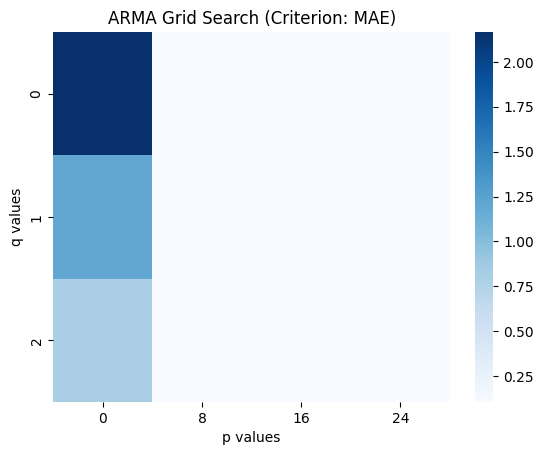

In [68]:
# Visualize the mae_grid with a heatmap
sns.heatmap(mae_df, cmap="Blues")

plt.xlabel("p values")
plt.ylabel("q values")
plt.title("ARMA Grid Search (Criterion: MAE)");

From the heatmap, we see that when our p_params was set to 0, the model does not relatively perform well. However, it does well on other parameters.

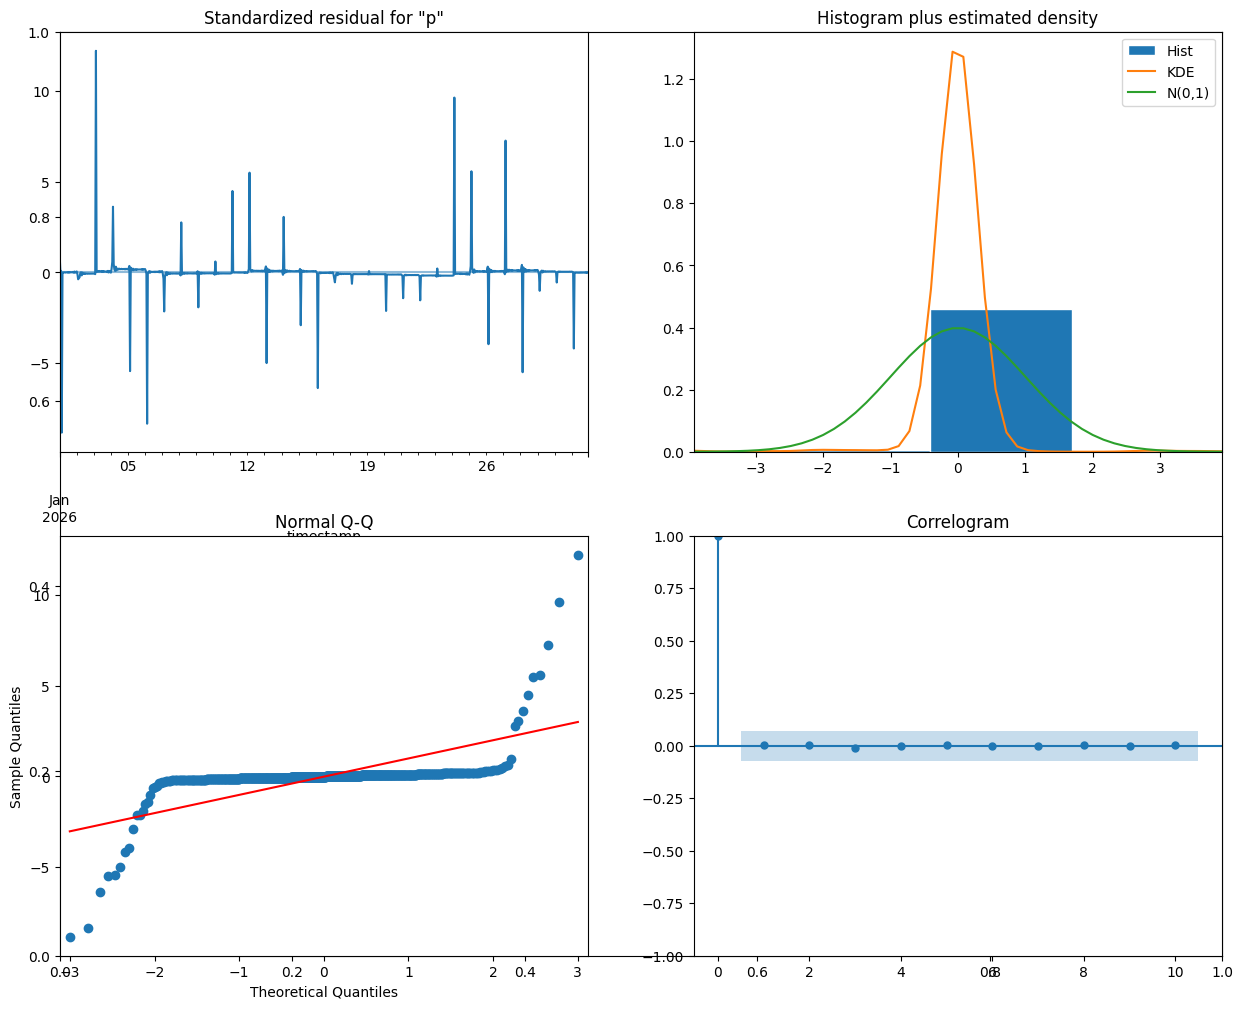

In [70]:
# To get a quick sense of whether our model is doing better or not
fig, ax = plt.subplots(figsize=(15, 12))
model.plot_diagnostics(fig=fig);

EVALUATE

In [73]:
df_pred_wfv = pd.Series()
history = df_train.copy()

for i in range(len(df_test)):
    model = ARIMA(history, order=(8, 0, 0)).fit()
    next_pred = model.forecast()
    df_pred_wf = pd.concat([df_pred_wfv, next_pred])
    history = pd.concat([history, df_test[next_pred.index]])

C:\Users\Johnt\AppData\Local\Temp\ipykernel_3668\4085158863.py:7: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pred_wf = pd.concat([df_pred_wfv, next_pred])
C:\Users\Johnt\AppData\Local\Temp\ipykernel_3668\4085158863.py:7: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pred_wf = pd.concat([df_pred_wfv, next_pred])
C:\Users\Johnt\AppData\Local\Temp\ipykernel_3668\4085158863.py:7: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the resul

In [74]:
# Calculate the MAE
test_mae = mean_absolute_error(df_test, df_pred_wfv)
print("Test MAE (walk forward validation):", round(test_mae, 2))

ValueError: Found input variables with inconsistent numbers of samples: [24, 0]

In [ ]:
df_predictions = pd.DataFrame({"y_test": df_test, "df_pred_wfv": df_pred_wfv})
fig = px.line(df_predictions, labels={"values": "PM2.5"})
fig.show()